# Phase 2A: basic within-frame geometry

Descriptive implementation validation in native StatsBomb 120 × 80 units. The eight locked metric families emit nine numeric outputs. Each original frame has six literal subset/goalkeeper variants. These are partial visible records, not full-team or tactical measurements.

Run `python scripts/geometry_diagnostics.py` from the repository root to generate the derived tables. This notebook reads compact summaries and rejects an unknown or different source revision. All geometry and summaries are computed in the reusable package; no raw records are saved.

In [1]:
%matplotlib inline
from pathlib import Path
from IPython.display import display
from leverkusen.spatial.diagnostics import read_geometry_diagnostics
from leverkusen.visualization.geometry import (
    plot_distributions, plot_by_valid_points, plot_goalkeeper_sensitivity,
)

root = Path.cwd() if (Path.cwd() / 'config/project.yaml').is_file() else Path.cwd().parent
summaries = read_geometry_diagnostics(root / 'outputs/diagnostics')
display(summaries['inventory'])
display(summaries['match_summary'])

,original_frames,variant_rows,matches_with_frames,statsbomb_revision
0,118581,711486,34,533862946a73608c134d18b78226b6371ce7173c


,match_id,events,original_frames,variant_rows,frames_load_status,frames_load_error,statsbomb_revision,source_base_url,retrieved_at_utc
0,3895302,4223,3525,21150,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:57:47.318608+00:00
1,3895292,3843,3195,19170,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:57:58.468962+00:00
2,3895333,3549,2950,17700,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:09.782972+00:00
3,3895340,3315,2847,17082,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:20.610007+00:00
4,3895348,4133,3562,21372,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:33.772695+00:00
5,3895286,3894,3434,20604,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:58:48.857965+00:00
6,3895220,4258,3757,22542,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:02.026975+00:00
7,3895250,3826,3410,20460,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:14.963602+00:00
8,3895266,4104,3623,21738,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:28.007176+00:00
9,3895275,3909,3341,20046,loaded,NaN,533862946a73608c134d18b78226b6371ce7173c,https://raw.githubusercontent.com/hudl/open-da...,2026-09-07T23:59:40.710549+00:00


## Availability and status

Count is zero for known-empty selections; an unavailable frame has NA measurements. Every other NA is accompanied by a metric-specific reason. Centroid components share one status rule. The tables retain all rows, including actor ambiguity and low visible-area coverage. This is an inventory of diagnostic measurements; the registry's later primary-comparison ambiguity policy is not applied here.

In [2]:
display(summaries['metric_summary'])
display(summaries['metric_status'])
display(summaries['anomalies'])

,selected_subset,goalkeeper_policy,metric,rows,available,na,na_percent,mean,std,min,p05,p25,median,p75,p95,max,statsbomb_revision
0,all_visible,included,visible_player_count,118581,118581,0,0.000000,16.471290,3.120971,1.000000,11.000000,14.000000,17.000000,19.000000,20.000000,22.000000,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,centroid_x,118581,118581,0,0.000000,63.806991,26.356173,3.099943,18.089736,43.568488,66.138246,85.053678,103.246848,118.677691,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,included,centroid_y,118581,118581,0,0.000000,40.174659,11.653331,3.205394,21.231619,31.241141,40.167044,49.157679,58.922186,75.576509,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,included,visible_width,118581,118581,0,0.000000,47.464932,11.092361,0.000000,28.990084,39.955072,47.524532,55.377362,65.637942,81.286486,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,included,visible_depth,118581,118581,0,0.000000,33.689701,7.986431,0.000000,21.924168,28.563324,32.954542,38.021937,47.994070,110.967021,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,included,convex_hull_area,118581,118574,7,0.005903,1031.928057,393.677325,2.573681,430.826141,757.614800,1009.966918,1276.996848,1700.748408,4304.400473,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,included,mean_pairwise_distance,118581,118580,1,0.000843,21.272467,3.969144,5.299529,14.244654,18.825975,21.497648,23.974184,27.356049,39.737569,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,included,median_pairwise_distance,118581,118580,1,0.000843,20.140406,3.936288,5.012747,13.177037,17.778163,20.344390,22.745449,26.220053,39.547351,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,included,mean_nearest_neighbor_distance,118581,118580,1,0.000843,6.374906,1.568486,1.203826,4.014342,5.323020,6.286875,7.259955,9.107558,25.855086,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,excluded,visible_player_count,118581,118581,0,0.000000,16.071580,3.202193,0.000000,10.000000,14.000000,17.000000,19.000000,20.000000,21.000000,533862946a73608c134d18b78226b6371ce7173c


,selected_subset,goalkeeper_policy,metric,status,rows,statsbomb_revision
0,all_visible,included,visible_player_count,ok,118581,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,centroid_x,ok,118581,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,included,centroid_y,ok,118581,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,included,visible_width,ok,118581,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,included,visible_depth,ok,118581,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...
89,teammate_false,excluded,mean_pairwise_distance,insufficient_points,174,533862946a73608c134d18b78226b6371ce7173c
90,teammate_false,excluded,median_pairwise_distance,ok,118407,533862946a73608c134d18b78226b6371ce7173c
91,teammate_false,excluded,median_pairwise_distance,insufficient_points,174,533862946a73608c134d18b78226b6371ce7173c
92,teammate_false,excluded,mean_nearest_neighbor_distance,ok,118407,533862946a73608c134d18b78226b6371ce7173c


,flag,variant_rows,original_frames,statsbomb_revision
0,coincident_records,198,50,533862946a73608c134d18b78226b6371ce7173c
1,multiple_actor,24,4,533862946a73608c134d18b78226b6371ce7173c
2,out_of_bounds_points,45565,11508,533862946a73608c134d18b78226b6371ce7173c


## Observed distributions

All six variants use shared display bins for each metric. Count is in records; hull area is in squared native units; other values are in native units. Histogram binning sets no visibility threshold.

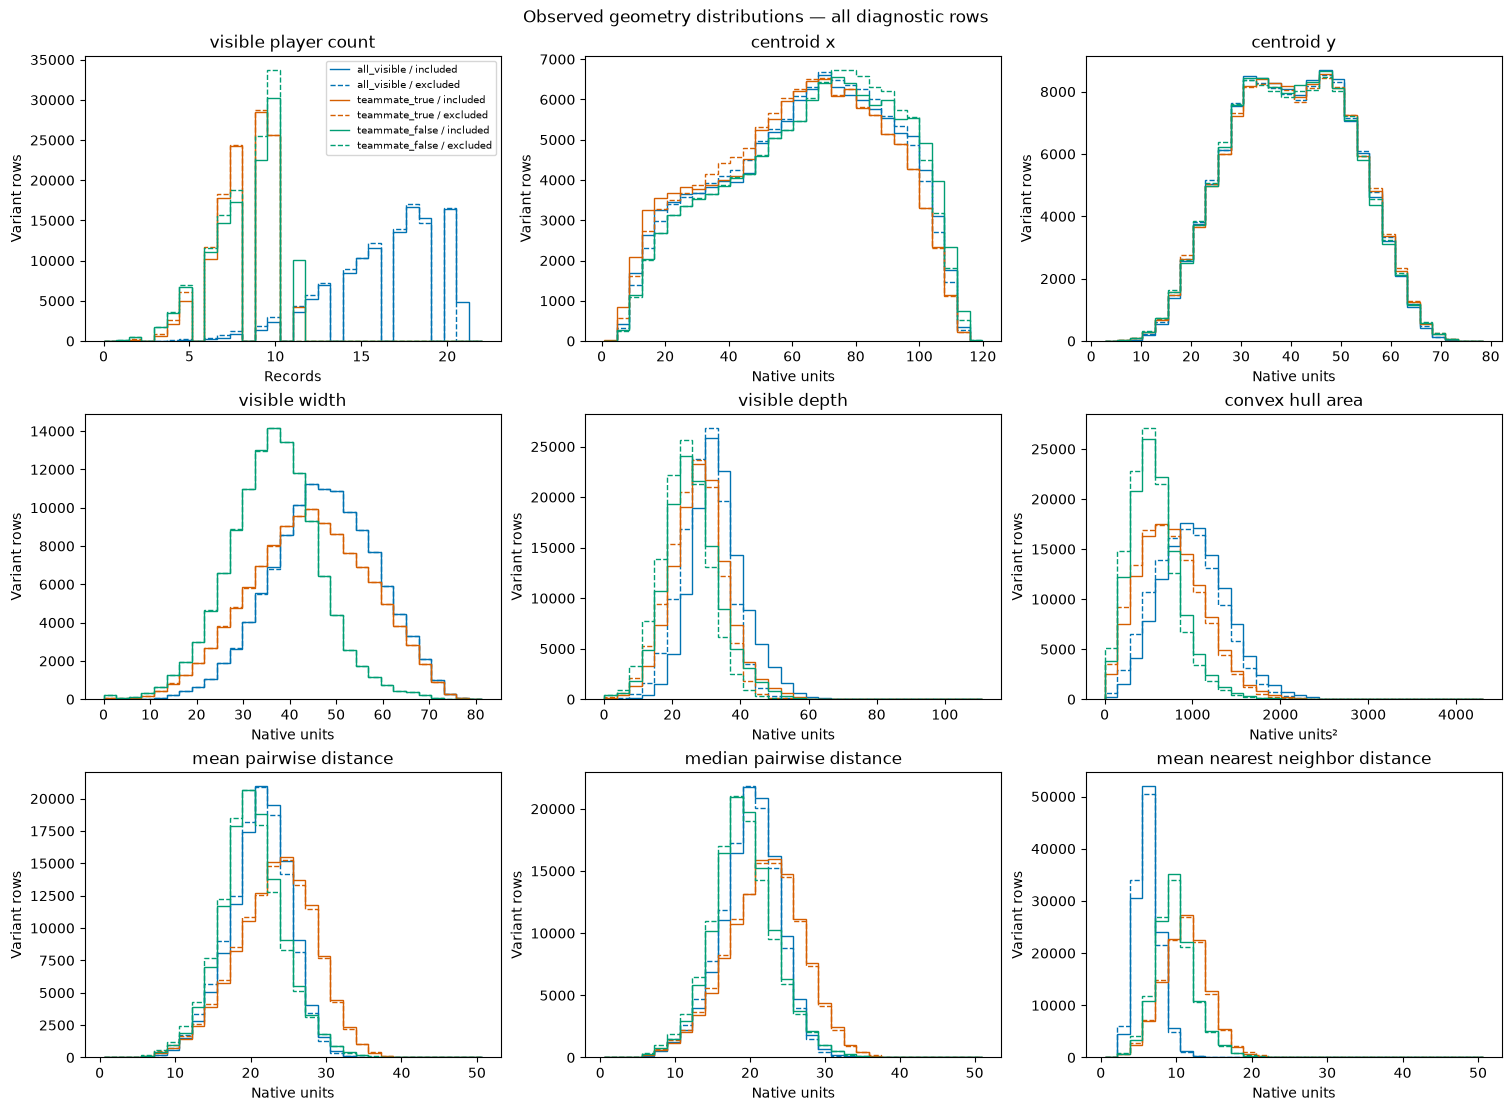

In [3]:
figure = plot_distributions(summaries['histograms'])

## Goalkeeper sensitivity

Differences are **excluded minus included**, paired by match, original frame ordinal and literal subset. `excluded` retains only `keeper=False`. Unknown keeper omissions are reported separately. Tables show all pairs and pairs with at least one record removed. Plot means use the latter group and only jointly defined metric values; consult availability denominators. Different metric minima can make the paired samples differ.

,selected_subset,scope,metric,delta_direction,rows,available,na,na_percent,mean,std,...,p25,median,p75,p95,max,pairs_with_keeper_removal,pairs_with_unknown_keeper_removal,changed_pairs,mean_absolute_delta,statsbomb_revision
0,all_visible,all_pairs,visible_player_count,excluded_minus_included,118581,118581,0,0.000000,-0.399710,0.489910,...,-1.000000,0.000000,0.000000,0.000000,0.000000,47394,0,47394,0.399710,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,all_pairs,centroid_x,excluded_minus_included,118581,118580,1,0.000843,0.045734,0.966287,...,0.000000,0.000000,0.000000,1.921518,12.526461,47394,0,47393,0.556485,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,all_pairs,centroid_y,excluded_minus_included,118581,118580,1,0.000843,0.002562,0.361687,...,0.000000,0.000000,0.000000,0.610513,7.466498,47394,0,47393,0.176888,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,all_pairs,visible_width,excluded_minus_included,118581,118580,1,0.000843,-0.016687,0.355091,...,0.000000,0.000000,0.000000,0.000000,0.000000,47394,0,556,0.016687,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,all_pairs,visible_depth,excluded_minus_included,118581,118580,1,0.000843,-4.167210,6.489208,...,-8.139859,0.000000,0.000000,0.000000,0.000000,47394,0,45089,4.167210,533862946a73608c134d18b78226b6371ce7173c
5,all_visible,all_pairs,convex_hull_area,excluded_minus_included,118581,118562,19,0.016023,-87.756434,145.908657,...,-146.016491,0.000000,0.000000,0.000000,0.000000,47394,0,46831,87.756434,533862946a73608c134d18b78226b6371ce7173c
6,all_visible,all_pairs,mean_pairwise_distance,excluded_minus_included,118581,118574,7,0.005903,-0.335259,0.668195,...,-0.540009,0.000000,0.000000,0.000000,7.396091,47394,0,47387,0.361660,533862946a73608c134d18b78226b6371ce7173c
7,all_visible,all_pairs,median_pairwise_distance,excluded_minus_included,118581,118574,7,0.005903,-0.343683,0.776539,...,-0.477361,0.000000,0.000000,0.000000,6.764277,47394,0,45716,0.385460,533862946a73608c134d18b78226b6371ce7173c
8,all_visible,all_pairs,mean_nearest_neighbor_distance,excluded_minus_included,118581,118574,7,0.005903,-0.162221,0.381839,...,-0.306796,0.000000,0.000000,0.014408,14.118107,47394,0,47387,0.204189,533862946a73608c134d18b78226b6371ce7173c
9,all_visible,records_removed,visible_player_count,excluded_minus_included,47394,47394,0,0.000000,-1.000084,0.009187,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,47394,0,47394,1.000084,533862946a73608c134d18b78226b6371ce7173c


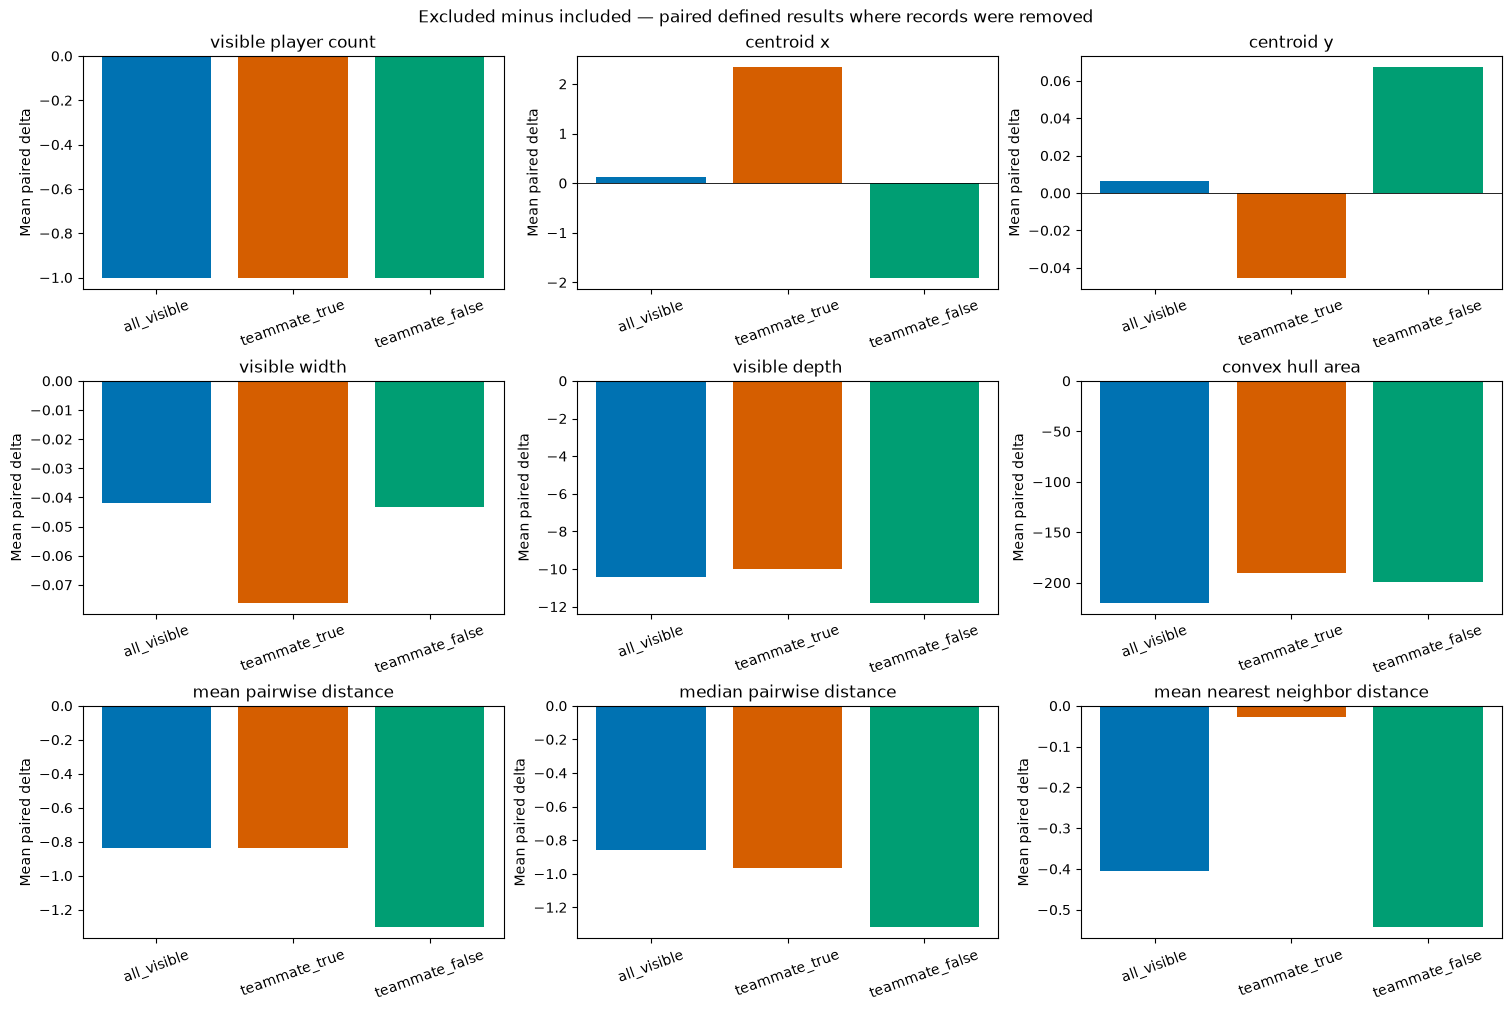

In [4]:
display(summaries['goalkeeper_sensitivity'])
figure = plot_goalkeeper_sensitivity(summaries['goalkeeper_sensitivity'])

## Dependence on selected valid-point count

Strata use the exact number of selected valid records, separately for each subset/keeper variant. Means describe composition and observation differences across strata; they do not establish a full-team shape or tactical effect. The table supplies sample counts and NA rates, including sparse strata.

,selected_subset,goalkeeper_policy,n_valid_points_used,metric,rows,available,na,na_percent,mean,std,min,p05,p25,median,p75,p95,max,statsbomb_revision
0,all_visible,included,1,visible_player_count,1,1,0,0.0,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,533862946a73608c134d18b78226b6371ce7173c
1,all_visible,included,1,centroid_x,1,1,0,0.0,9.100000,NaN,9.100000,9.100000,9.100000,9.100000,9.100000,9.100000,9.100000,533862946a73608c134d18b78226b6371ce7173c
2,all_visible,included,1,centroid_y,1,1,0,0.0,36.500000,NaN,36.500000,36.500000,36.500000,36.500000,36.500000,36.500000,36.500000,533862946a73608c134d18b78226b6371ce7173c
3,all_visible,included,1,visible_width,1,1,0,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,533862946a73608c134d18b78226b6371ce7173c
4,all_visible,included,1,visible_depth,1,1,0,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,533862946a73608c134d18b78226b6371ce7173c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,teammate_false,excluded,11,visible_depth,30,30,0,0.0,26.368894,13.229105,8.206526,9.291440,15.501970,22.848811,35.267539,52.107770,52.382760,533862946a73608c134d18b78226b6371ce7173c
815,teammate_false,excluded,11,convex_hull_area,30,30,0,0.0,581.724219,443.471777,54.404752,70.872105,138.696868,449.675352,1016.168642,1261.357766,1328.405390,533862946a73608c134d18b78226b6371ce7173c
816,teammate_false,excluded,11,mean_pairwise_distance,30,30,0,0.0,16.530486,7.217471,5.775810,6.300357,8.321684,16.509510,23.108703,25.844235,28.364683,533862946a73608c134d18b78226b6371ce7173c
817,teammate_false,excluded,11,median_pairwise_distance,30,30,0,0.0,15.444811,6.770700,5.105827,5.940909,8.717889,14.378556,21.755108,24.926346,25.215685,533862946a73608c134d18b78226b6371ce7173c


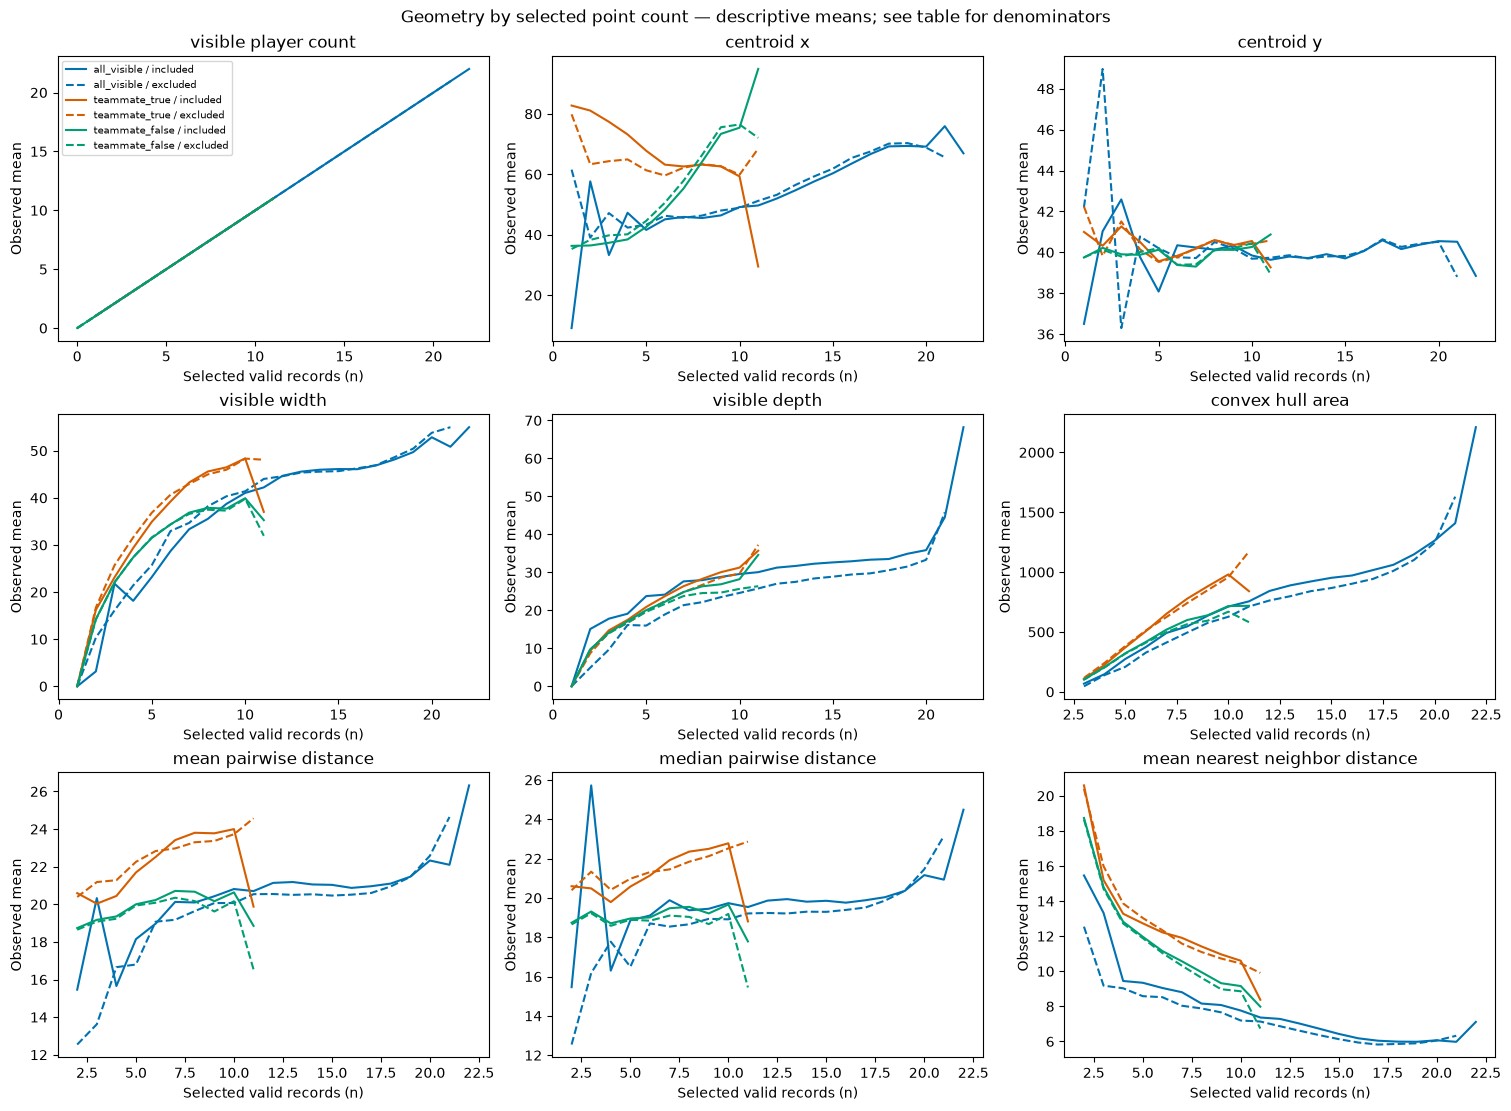

In [5]:
display(summaries['by_valid_points'])
figure = plot_by_valid_points(summaries['by_valid_points'])

## Validation boundary

Coincident records retain their original weights. Multiple/unknown actor statuses are flags, without actor selection or deduplication. Finite out-of-bounds points remain measured and flagged. There is no coordinate flipping, metre conversion, zone assignment, eligibility threshold, sequence construction or later metric here.

Implementation checks and empirical results are recorded in `report/technical_appendix.md`. Representative-frame review, visibility calibration, identity ambiguity and direction-dependent interpretation remain separate work.